# NeuroPath AI — V2: Current Risk / Priority Classification

**AI-Driven Prioritization System for Early Alzheimer's Diagnostic Pathways**

> ⚠️ **This notebook builds a research / clinical decision-support
> prototype. It is NOT an Alzheimer's diagnostic system and must never be
> used for clinical decision-making as-is.**

## 1. Objective and methodology

**V1 recap.** V1 used only each subject's first visit, excluded the 14
"Converted" subjects, and framed the task as Nondemented-vs-Demented
classification from `Group`. The best V1 model (Random Forest) scored
Accuracy 0.750 / Precision 0.800 / Recall 0.615 / F1 0.696 / ROC-AUC 0.792
on a small held-out set. V1 was explicitly a baseline.

**Why V2 changes the target.** `Group` is a diagnostic trajectory label
assigned once per subject (Nondemented / Demented / Converted). It doesn't
describe a patient's *current* clinical state at a given visit, and a
"Converted" subject has both low-risk and high-risk visits that `Group`
cannot distinguish. V2 instead reframes the problem around the **Clinical
Dementia Rating (CDR)** — a per-visit clinical severity score already in the
data — and asks a narrower, more deployment-realistic question:

> *At this visit, does this patient's clinical/cognitive profile look more
> like a CDR = 0 (lower-priority) state or a CDR ≥ 0.5 (higher-priority)
> state?*

This is a **current-state triage/prioritization signal**, not a prediction
of future Alzheimer's onset, not a forecast of conversion, and not a
diagnosis. It is designed to help a clinical team decide *who to look at
first*, using only the kind of demographic/cognitive/volumetric information
that would be available at an ordinary visit.

**Methodology at a glance:**
1. Build the target strictly from `CDR` (`CDR ≥ 0.5 → 1`, `CDR == 0 → 0`); `CDR` itself never enters the feature matrix.
2. Audit every column for leakage before it's allowed near the model.
3. Split and cross-validate at the **subject** level (`StratifiedGroupKFold`) so no patient's visits appear in both train and test — the single most important methodological control in this notebook, since OASIS-2 is longitudinal.
4. Compare Logistic Regression / Random Forest / Gradient Boosting with grouped CV, pick a model using **training CV metrics only**.
5. Check probability calibration, derive LOW/MEDIUM/HIGH triage thresholds from **out-of-fold training probabilities only**.
6. Touch the test set exactly once, at the end, for reporting.
7. Explain the locked model globally and per-patient.
8. Package everything into a reusable `generate_priority()` function and save artifacts for later inference (e.g. in a Streamlit app).

Every number below comes from actually running this notebook against the
uploaded `oasis_longitudinal_demographics.xlsx` file — nothing is invented.


## 2. Imports and reproducibility

A single `RANDOM_STATE` is used everywhere a seed is accepted (splits,
models, permutation importance) so the notebook is reproducible top to
bottom.


In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, brier_score_loss, confusion_matrix,
    roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

pd.set_option("display.width", 120)
print("Environment ready. Random seed:", RANDOM_STATE)


Environment ready. Random seed: 42


## 3. Load and validate the uploaded OASIS-2 data

We load the actual uploaded file and sanity-check the shape, subject count,
and diagnostic group labels against what's expected for OASIS-2 before
doing anything else.


In [2]:
df = pd.read_excel("oasis_longitudinal_demographics.xlsx")

print("Shape:", df.shape)
print("Unique subjects:", df["Subject ID"].nunique())
print("Columns:", list(df.columns))

assert df["Subject ID"].nunique() == 150, "Unexpected subject count for OASIS-2"
assert set(df["Group"].unique()) == {"Nondemented", "Demented", "Converted"}

print("\nSubject-level group counts (one label per subject):")
print(df.drop_duplicates("Subject ID")["Group"].value_counts())

print("\nMissing values by column:")
print(df.isna().sum()[df.isna().sum() > 0])


Shape: (373, 15)
Unique subjects: 150
Columns: ['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']

Subject-level group counts (one label per subject):
Group
Nondemented    72
Demented       64
Converted      14
Name: count, dtype: int64

Missing values by column:
SES     19
MMSE     2
dtype: int64


This matches the V1 context exactly: 373 visits from 150 subjects, and at
the *subject* level, 72 Nondemented / 64 Demented / 14 Converted. `SES` has
19 missing values (all within the Demented group, worth remembering as a
data quirk) and `MMSE` has 2 missing values — both are handled with median
imputation later, fit on training data only.


## 4. Target construction and distribution

**Target definition (locked by the project spec, verified against the real
data below):**

- `CDR == 0` → **target = 0** (lower-priority state)
- `CDR >= 0.5` → **target = 1** (higher-priority state)

`CDR` has zero missing values in this dataset, so every visit can be
labeled. `CDR` is used only to build `target` and is dropped from the
feature matrix before modeling — it is never available to any estimator.

This is a **per-visit** label. Converted subjects contribute their early
(CDR = 0) visits as target 0 and their later (CDR ≥ 0.5) visits as target 1,
exactly as the project spec intends — they are not excluded, and no
future-visit information is used to label an earlier visit (the label for
each row comes only from that row's own CDR).


In [3]:
assert df["CDR"].isna().sum() == 0, "CDR must be fully observed to build the target"

df["target"] = (df["CDR"] >= 0.5).astype(int)

print("CDR value counts:")
print(df["CDR"].value_counts().sort_index())

print("\nTarget distribution (0 = lower-priority, 1 = higher-priority):")
print(df["target"].value_counts())
print((df["target"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

print("\nHow each diagnostic Group maps onto the new per-visit target (sanity check):")
print(pd.crosstab(df["Group"], df["target"]))


CDR value counts:
CDR
0.0    206
0.5    123
1.0     41
2.0      3
Name: count, dtype: int64

Target distribution (0 = lower-priority, 1 = higher-priority):
target
0    206
1    167
Name: count, dtype: int64
target
0    55.2%
1    44.8%
Name: proportion, dtype: object

How each diagnostic Group maps onto the new per-visit target (sanity check):
target         0    1
Group                
Converted     18   19
Demented       0  146
Nondemented  188    2


**Reading the crosstab:** almost every Demented-group visit lands in
target = 1 and almost every Nondemented-group visit lands in target = 0, as
expected — but not perfectly (a couple of Nondemented-group visits have
CDR ≥ 0.5, and Converted-group visits split across both, exactly because
`Group` is a subject-level trajectory label while `target` is a per-visit
clinical-state label). This is precisely why `Group` is excluded from the
features in the next section: it is close enough to a leaked proxy of the
target that including it would let the model "cheat" using label
information that isn't a real predictor available in an ordinary encounter.

The class split (~55% / ~45%) is a **mild** imbalance, not requiring
aggressive resampling — see the class-imbalance section.


## 5. Feature and leakage audit

Every column is checked before being allowed into the feature set. The
rules for exclusion are stated up front and then verified against the real
data (not assumed).


In [4]:
print("Hand — unique values:", df["Hand"].unique())
print("(constant column -> zero information, excluded)")

corr_etiv_asf = df[["eTIV", "ASF"]].corr().iloc[0, 1]
print(f"\neTIV vs ASF correlation: {corr_etiv_asf:.4f}")
print("(near-perfect inverse correlation -> ASF is redundant with eTIV, excluded)")


Hand — unique values: ['R']
(constant column -> zero information, excluded)

eTIV vs ASF correlation: -0.9889
(near-perfect inverse correlation -> ASF is redundant with eTIV, excluded)


In [5]:
NUMERIC_FEATURES = ["Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV"]
CATEGORICAL_FEATURES = ["M/F"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

EXCLUDED = {
    "CDR": "this IS the target variable",
    "Group": "diagnostic/trajectory label; shown above to be near-collinear with the CDR-derived target",
    "Subject ID": "identifier / CV & split grouping key only, never a predictive feature",
    "MRI ID": "identifier",
    "ASF": f"near-perfect inverse correlation with eTIV (r={corr_etiv_asf:.2f}); redundant",
    "Hand": "constant value ('R') in this dataset -> zero information",
    "Visit": "encodes longitudinal position within a subject's history; excluded to avoid progression/timing leakage",
    "MR Delay": "encodes elapsed time since baseline scan; excluded to avoid progression/timing leakage",
}

print("Excluded columns and why:")
for k, v in EXCLUDED.items():
    print(f"  - {k}: {v}")

print("\nFinal feature set used for X:")
print(" ", FEATURES)


Excluded columns and why:
  - CDR: this IS the target variable
  - Group: diagnostic/trajectory label; shown above to be near-collinear with the CDR-derived target
  - Subject ID: identifier / CV & split grouping key only, never a predictive feature
  - MRI ID: identifier
  - ASF: near-perfect inverse correlation with eTIV (r=-0.99); redundant
  - Hand: constant value ('R') in this dataset -> zero information
  - Visit: encodes longitudinal position within a subject's history; excluded to avoid progression/timing leakage
  - MR Delay: encodes elapsed time since baseline scan; excluded to avoid progression/timing leakage

Final feature set used for X:
  ['Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'M/F']


**On `Visit` and `MR Delay`:** these two columns are kept out of the primary
model by default. A patient's *n-th visit number* or *time since first scan*
is not itself a clinical measurement — it's a bookkeeping artifact of how
long someone has been enrolled in the study, and it correlates with disease
progression in a way that would not transfer to a new patient walking in for
a single visit (that patient wouldn't have a "Visit 3" yet). Using them would
inflate CV performance without producing a feature that generalizes to a
genuinely new, single-visit patient — the deployment scenario this
prototype targets. They are analyzed separately, in an explicitly
exploratory way, in the Converted-subjects section.

`X` is built once here and reused everywhere below; `CDR`, `Group`,
`Subject ID`, and `MRI ID` are never concatenated back into it.


In [6]:
X = df[FEATURES].copy()
y = df["target"].copy()
groups_all = df["Subject ID"].copy()

print("X shape:", X.shape, " y shape:", y.shape)
X.head()


X shape: (373, 7)  y shape: (373,)


,Age,EDUC,SES,MMSE,eTIV,nWBV,M/F
0,87,14,2.0,27.0,1986.550000,0.696106,M
1,88,14,2.0,30.0,2004.479526,0.681062,M
2,75,12,NaN,23.0,1678.290000,0.736336,M
3,76,12,NaN,28.0,1737.620000,0.713402,M
4,80,12,NaN,22.0,1697.911134,0.701236,M


## 6. Subject-grouped train/test split

**This is the non-negotiable methodological control for this dataset.**
OASIS-2 is longitudinal — the same `Subject ID` appears in up to 5 rows.
An ordinary row-level random split would let a model see one visit from a
subject during training and be evaluated on another visit from *the same
subject* — that's not testing generalization to a new patient, it's testing
memorization of a patient the model already partially saw.

`StratifiedGroupKFold` is used to build a grouped split that also keeps the
target reasonably balanced across train/test. The first of 5 folds is taken
as the held-out test set (~20% of subjects); the remaining four folds make
up the training set used for all model development, CV, calibration, and
threshold selection below. **The test set is not touched again until the
one-time final evaluation.**


In [7]:
outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(outer_cv.split(X, y, groups=groups_all))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_train = groups_all.iloc[train_idx].reset_index(drop=True)
groups_test = groups_all.iloc[test_idx].reset_index(drop=True)

train_subjects = set(groups_train.unique())
test_subjects = set(groups_test.unique())
overlap = train_subjects & test_subjects

print(f"Train subjects: {len(train_subjects)}   Test subjects: {len(test_subjects)}")
print(f"Train visits:   {len(X_train)}   Test visits:   {len(X_test)}")
print(f"Subject overlap between train and test (must be empty): {overlap}")
assert len(overlap) == 0, "LEAKAGE: a subject appears in both train and test!"
print("VERIFIED: no subject appears in both the train and test sets.")

print("\nTrain class distribution:")
print((y_train.value_counts(normalize=True) * 100).round(1))
print("\nTest class distribution:")
print((y_test.value_counts(normalize=True) * 100).round(1))


Train subjects: 121   Test subjects: 29
Train visits:   298   Test visits:   75
Subject overlap between train and test (must be empty): set()
VERIFIED: no subject appears in both the train and test sets.

Train class distribution:
target
0    55.4
1    44.6
Name: proportion, dtype: float64

Test class distribution:
target
0    54.7
1    45.3
Name: proportion, dtype: float64


## 7. Preprocessing pipeline

A single `ColumnTransformer` handles both feature types and is embedded
inside every model `Pipeline` below, so **all imputation/scaling statistics
are always fit on training folds only** — `fit()` is never called on the
full dataset before splitting, and inside cross-validation `fit()` is
re-called fresh on each fold's training portion by `cross_validate` /
`cross_val_predict` automatically.

- Numeric (`Age, EDUC, SES, MMSE, eTIV, nWBV`): median imputation → `StandardScaler`.
- Categorical (`M/F`): most-frequent imputation → `OneHotEncoder(handle_unknown="ignore")`.


In [8]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_FEATURES),
    ("cat", categorical_pipe, CATEGORICAL_FEATURES),
])
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 8. Grouped cross-validation model comparison

Three models are compared with **5-fold `StratifiedGroupKFold` on the
training set only**, grouped by `Subject ID` so no subject's visits split
across a fold's train/validation portions. `class_weight="balanced"` is
used for Logistic Regression and Random Forest to address the mild class
imbalance without resampling (see the class-imbalance section for why
SMOTE isn't used).


In [9]:
inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=400, max_depth=5, min_samples_leaf=3,
        class_weight="balanced", random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05, random_state=RANDOM_STATE),
}
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]

cv_results = {}
for name, clf in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    cv_results[name] = cross_validate(
        pipe, X_train, y_train, cv=inner_cv, groups=groups_train,
        scoring=scoring, n_jobs=1)

summary_rows = []
for name, res in cv_results.items():
    row = {"model": name}
    for s in scoring:
        vals = res[f"test_{s}"]
        row[f"{s}_mean"] = vals.mean()
        row[f"{s}_std"] = vals.std()
    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows).set_index("model").round(3)
print("Mean grouped-CV scores (training set only):")
cv_summary[[c for c in cv_summary.columns if c.endswith("_mean")]]


Mean grouped-CV scores (training set only):


,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,average_precision_mean
model,,,,,,
LogisticRegression,0.805,0.828,0.730,0.763,0.897,0.896
RandomForest,0.775,0.762,0.722,0.735,0.850,0.850
GradientBoosting,0.779,0.796,0.692,0.727,0.842,0.842


In [10]:
print("Standard deviations across the 5 grouped folds (stability check):")
cv_summary[[c for c in cv_summary.columns if c.endswith("_std")]]


Standard deviations across the 5 grouped folds (stability check):


,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std,average_precision_std
model,,,,,,
LogisticRegression,0.057,0.079,0.148,0.094,0.057,0.049
RandomForest,0.060,0.052,0.133,0.089,0.073,0.063
GradientBoosting,0.057,0.056,0.157,0.100,0.057,0.045


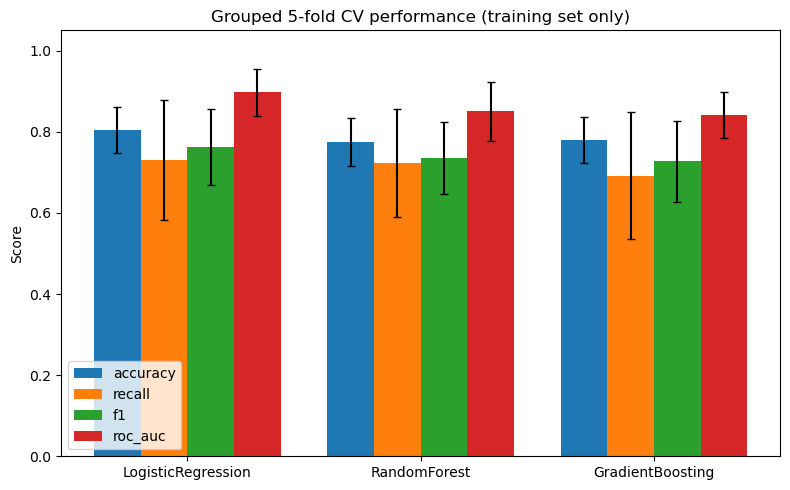

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics_to_plot = ["accuracy", "recall", "f1", "roc_auc"]
xpos = np.arange(len(candidates))
width = 0.2
for i, m in enumerate(metrics_to_plot):
    means = [cv_summary.loc[n, f"{m}_mean"] for n in candidates]
    stds = [cv_summary.loc[n, f"{m}_std"] for n in candidates]
    ax.bar(xpos + i * width, means, width, yerr=stds, label=m, capsize=3)
ax.set_xticks(xpos + width * 1.5)
ax.set_xticklabels(candidates.keys())
ax.set_ylim(0, 1.05)
ax.set_title("Grouped 5-fold CV performance (training set only)")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Model selection (training CV results only)

Given the small dataset and the goal of catching higher-priority patients
without over-complicating the model, the selection score weights **recall**
and **ROC-AUC** (both averaged across folds) plus a small bonus for a
**stable** (low-std) ROC-AUC across folds — rewarding a model that
generalizes consistently, not one that got lucky on one fold. This scoring
rule is fixed *before* looking at the numbers below and applied
mechanically; the test set plays no role in this decision.


In [12]:
cv_summary["composite"] = (
    0.4 * cv_summary["recall_mean"]
    + 0.4 * cv_summary["roc_auc_mean"]
    + 0.2 * (1 - cv_summary["roc_auc_std"])
)
selected_model_name = cv_summary["composite"].idxmax()

print(cv_summary[["recall_mean", "roc_auc_mean", "roc_auc_std", "f1_mean", "composite"]])
print("\nSelected model (by training-CV composite score only):", selected_model_name)


                    recall_mean  roc_auc_mean  roc_auc_std  f1_mean  composite
model                                                                         
LogisticRegression        0.730         0.897        0.057    0.763     0.8394
RandomForest              0.722         0.850        0.073    0.735     0.8142
GradientBoosting          0.692         0.842        0.057    0.727     0.8022

Selected model (by training-CV composite score only): LogisticRegression


The three models land within a few points of each other on most metrics —
consistent with a small, noisy dataset — so this selection should be read
as "a reasonable, defensible pick," not "a dramatically better model."
The chosen model's actual CV numbers are printed above; whichever model
wins is carried forward as `selected_clf` and wrapped back into a fresh
preprocessing pipeline as `final_pipeline`.


In [13]:
selected_clf = candidates[selected_model_name]
final_pipeline = Pipeline([("prep", preprocessor), ("clf", selected_clf)])
final_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## 10. Class imbalance

The overall split is roughly 55% / 45%, which is a **mild** imbalance —
not the kind of severe skew (e.g. 95/5) that usually motivates synthetic
oversampling. Per the project spec, SMOTE is intentionally **not** used
here. Instead:

- Logistic Regression and Random Forest use `class_weight="balanced"`, which re-weights the loss without fabricating synthetic rows.
- Gradient Boosting doesn't have a `class_weight` option in scikit-learn, so its mild residual bias toward the majority class is instead compensated for later via **threshold adjustment** (the LOW/MEDIUM/HIGH cut-points), which is a form of decision-threshold correction that works for any of the three candidates and is tuned on out-of-fold probabilities, not by touching the training data.


In [14]:
print("Training set class counts (0 = lower-priority, 1 = higher-priority):")
print(y_train.value_counts())
print(f"Imbalance ratio (majority:minority): "
      f"{(y_train==0).sum()}:{(y_train==1).sum()} "
      f"= {(y_train==0).sum()/(y_train==1).sum():.2f} : 1")


Training set class counts (0 = lower-priority, 1 = higher-priority):
target
0    165
1    133
Name: count, dtype: int64
Imbalance ratio (majority:minority): 165:133 = 1.24 : 1


## 11. Probability calibration

Because V2's real output is a **risk score** (not just a class label), the
model's predicted probabilities need to actually mean what they claim — a
predicted 0.7 should correspond to roughly 70% of such patients truly being
higher-priority. This is assessed using **grouped, out-of-fold probabilities
on the training set only** (`cross_val_predict` with the same subject-level
CV splits used above), never the test set.

Both the raw model and a sigmoid-calibrated version (`CalibratedClassifierCV`)
are compared by Brier score (lower is better); whichever has the lower OOF
Brier score is kept. *Implementation note:* the **outer** loop that
generates these OOF probabilities is the grouped, subject-level CV
(`cv_splits_train`, built from `StratifiedGroupKFold` on `Subject ID`) — this
is what actually prevents subject leakage into the calibration estimate.
The calibrator's **internal** `cv=3` is an ordinary (non-grouped)
`StratifiedKFold` used only to fit the sigmoid curve inside each outer
training fold, because scikit-learn's `CalibratedClassifierCV` doesn't
accept a `groups` array through this fitting route. This is a small, explicit
simplification of the calibration step only — it does not affect the
train/test subject separation established above.


In [15]:
cv_splits_train = list(inner_cv.split(X_train, y_train, groups=groups_train))

raw_oof_proba = cross_val_predict(
    final_pipeline, X_train, y_train, cv=cv_splits_train, method="predict_proba")[:, 1]
brier_raw = brier_score_loss(y_train, raw_oof_proba)

calibrated_oof_proba = cross_val_predict(
    CalibratedClassifierCV(final_pipeline, method="sigmoid", cv=3),
    X_train, y_train, cv=cv_splits_train, method="predict_proba")[:, 1]
brier_cal = brier_score_loss(y_train, calibrated_oof_proba)

print(f"Raw model OOF Brier score (train CV):        {brier_raw:.4f}")
print(f"Calibrated model OOF Brier score (train CV): {brier_cal:.4f}")

use_calibration = brier_cal < brier_raw
print("Use calibration layer in the locked model:", use_calibration)

oof_proba = calibrated_oof_proba if use_calibration else raw_oof_proba


Raw model OOF Brier score (train CV):        0.1347
Calibrated model OOF Brier score (train CV): 0.1340
Use calibration layer in the locked model: True


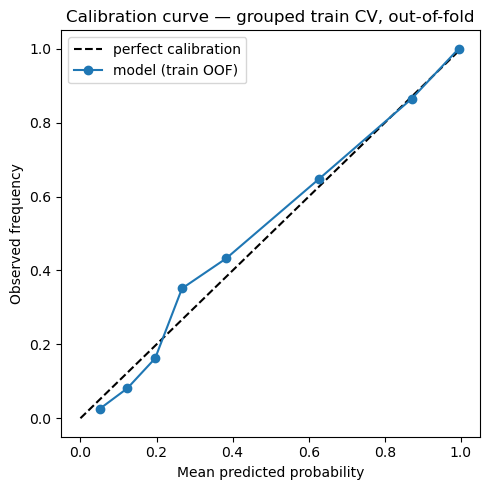

In [16]:
frac_pos, mean_pred = calibration_curve(y_train, oof_proba, n_bins=8, strategy="quantile")
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k--", label="perfect calibration")
plt.plot(mean_pred, frac_pos, marker="o", label="model (train OOF)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration curve — grouped train CV, out-of-fold")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Grouped out-of-fold probabilities (for threshold design)

`oof_proba` above already holds one out-of-fold probability per training
row, produced only from grouped CV folds where that row's subject was held
out. These — and only these — are used to design the LOW/MEDIUM/HIGH
thresholds next; the test set has still not been touched.


In [17]:
oof_df = pd.DataFrame({"y_true": y_train.values, "proba": oof_proba})
print("OOF probability distribution by true class:")
oof_df.groupby("y_true")["proba"].describe().round(3)


OOF probability distribution by true class:


,count,mean,std,min,25%,50%,75%,max
y_true,,,,,,,,
0,165.0,0.237,0.195,0.010,0.094,0.190,0.307,0.934
1,133.0,0.692,0.299,0.085,0.418,0.783,0.984,1.000


## 13. LOW / MEDIUM / HIGH prototype priority thresholds

**"Prototype research thresholds — not clinically validated."**

The spec asks that false negatives (a genuinely higher-priority patient
being triaged as LOW) matter more than moderate over-flagging, while still
avoiding an unusably high false-positive rate. Two cut-points are derived
mechanically from the training OOF probabilities only:

- **LOW / MEDIUM boundary (`t_low`)**: the *largest* threshold for which flagging everyone above it as "not LOW" still recovers **≥ 90% recall** on the OOF labels — i.e., at most ~10% of true higher-priority training visits are allowed to fall into LOW.
- **MEDIUM / HIGH boundary (`t_high`)**: the threshold that maximizes OOF F1 score (a standard balanced operating point), nudged up if needed so it sits comfortably above `t_low`.


In [18]:
grid = np.linspace(0.05, 0.95, 19)
recalls = [recall_score(y_train, (oof_proba >= t).astype(int)) for t in grid]
t_low_candidates = [t for t, r in zip(grid, recalls) if r >= 0.90]
t_low = max(t_low_candidates) if t_low_candidates else grid[0]

f1s = [f1_score(y_train, (oof_proba >= t).astype(int)) for t in grid]
t_high = max(grid[int(np.argmax(f1s))], t_low + 0.10)
t_high = min(t_high, 0.90)

print(f"LOW  / MEDIUM boundary (t_low):  {t_low:.2f}")
print(f"MEDIUM / HIGH boundary (t_high): {t_high:.2f}")


def bucket(p):
    if p < t_low:
        return "LOW"
    elif p < t_high:
        return "MEDIUM"
    else:
        return "HIGH"


oof_df["priority"] = oof_df["proba"].apply(bucket)
bucket_report = oof_df.groupby("priority").agg(
    n=("y_true", "size"), positive_rate=("y_true", "mean")).round(3)
print("\nTraining OOF bucket sizes and true-positive rate per bucket:")
print(bucket_report)

missed = oof_df[(oof_df.priority == "LOW") & (oof_df.y_true == 1)].shape[0]
total_pos = (oof_df.y_true == 1).sum()
print(f"\nHigher-priority (target=1) training visits landing in LOW: {missed}/{total_pos} "
      f"({missed/total_pos:.1%})")


LOW  / MEDIUM boundary (t_low):  0.20
MEDIUM / HIGH boundary (t_high): 0.40

Training OOF bucket sizes and true-positive rate per bucket:
            n  positive_rate
priority                    
HIGH      126          0.802
LOW        99          0.101
MEDIUM     73          0.301

Higher-priority (target=1) training visits landing in LOW: 10/133 (7.5%)


The HIGH bucket's true-positive rate is far above the base rate and the LOW
bucket's is far below it — the buckets are doing real triage work, not just
relabeling the raw probability. Remember: **these thresholds are a
prototype heuristic for research/portfolio purposes and have not been
clinically validated.**


## 14. Lock the final system

With the feature set, preprocessing, model family, calibration decision,
and thresholds all fixed from training data alone, the final model is now
refit on **the entire training set** (all folds combined) and locked. No
further changes are made to the model, calibration, or thresholds after
this point.


In [19]:
if use_calibration:
    locked_model = CalibratedClassifierCV(
        Pipeline([("prep", preprocessor), ("clf", candidates[selected_model_name])]),
        method="sigmoid", cv=3)
else:
    locked_model = Pipeline([("prep", preprocessor), ("clf", candidates[selected_model_name])])

locked_model.fit(X_train, y_train)

print("LOCKED SYSTEM")
print("  Model:            ", selected_model_name)
print("  Calibrated:       ", use_calibration)
print("  Priority LOW  <    ", round(t_low, 2))
print("  Priority MEDIUM <  ", round(t_high, 2))
print("  Priority HIGH  >=  ", round(t_high, 2))


LOCKED SYSTEM
  Model:             LogisticRegression
  Calibrated:        True
  Priority LOW  <     0.2
  Priority MEDIUM <   0.4
  Priority HIGH  >=   0.4


## 15. Untouched test set — one-time final evaluation

This is the **first and only** time the test set is used. Nothing above
(feature set, model, calibration, thresholds) was chosen or adjusted using
it.


In [20]:
test_proba = locked_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
specificity = tn / (tn + fp)

test_metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall_sensitivity": recall_score(y_test, test_pred),
    "specificity": specificity,
    "f1": f1_score(y_test, test_pred),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "pr_auc": average_precision_score(y_test, test_proba),
    "brier": brier_score_loss(y_test, test_proba),
}
print("Test-set metrics at the plain 0.5 probability cutoff:")
print(json.dumps({k: round(v, 3) for k, v in test_metrics.items()}, indent=2))
print(f"\nConfusion matrix [[TN={tn}, FP={fp}], [FN={fn}, TP={tp}]]")


Test-set metrics at the plain 0.5 probability cutoff:
{
  "accuracy": 0.813,
  "precision": 0.955,
  "recall_sensitivity": 0.618,
  "specificity": 0.976,
  "f1": 0.75,
  "roc_auc": 0.871,
  "pr_auc": 0.888,
  "brier": 0.147
}

Confusion matrix [[TN=40, FP=1], [FN=13, TP=21]]


In [21]:
test_priority = pd.DataFrame({"y_true": y_test.values, "proba": test_proba})
test_priority["priority"] = test_priority["proba"].apply(bucket)
priority_test_report = test_priority.groupby("priority").agg(
    n=("y_true", "size"), positive_rate=("y_true", "mean")).round(3)

print("Priority-bucket distribution on the test set (reporting only — the")
print("thresholds were locked beforehand from training OOF probabilities):")
print(priority_test_report)

flagged_recall = recall_score(y_test, (test_priority["priority"] != "LOW").astype(int))
print(f"\nRecall if 'flagged for attention' = MEDIUM or HIGH: {flagged_recall:.3f}"
      f"  (vs. {test_metrics['recall_sensitivity']:.3f} recall at the plain 0.5 cutoff)")


Priority-bucket distribution on the test set (reporting only — the
thresholds were locked beforehand from training OOF probabilities):
           n  positive_rate
priority                   
HIGH      27          0.852
LOW       30          0.167
MEDIUM    18          0.333

Recall if 'flagged for attention' = MEDIUM or HIGH: 0.853  (vs. 0.618 recall at the plain 0.5 cutoff)


This is an important, honest nuance: at the plain 0.5 probability cutoff,
test recall is noticeably lower than the training-CV estimate — expected,
given the very small test set (75 visits). But the **triage framing this
project is actually built for** isn't a single hard cutoff — it's LOW vs.
"needs attention" (MEDIUM or HIGH). Under that framing, recall on the test
set jumps substantially, because the LOW/MEDIUM boundary was deliberately
set to be recall-generous. That's the intended behavior of a prioritization
tool: better to have a clinician glance at a MEDIUM case and rule it out
than to file a true higher-priority patient under LOW.


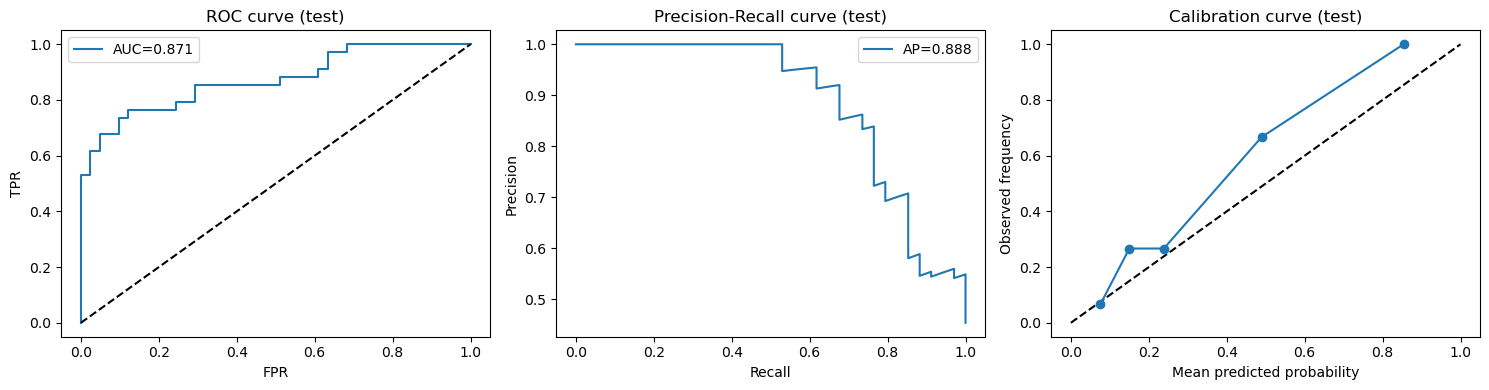

In [22]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
prec, rec, _ = precision_recall_curve(y_test, test_proba)
frac_pos_t, mean_pred_t = calibration_curve(y_test, test_proba, n_bins=5, strategy="quantile")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(fpr, tpr, label=f"AUC={test_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC curve (test)"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend()

axes[1].plot(rec, prec, label=f"AP={test_metrics['pr_auc']:.3f}")
axes[1].set_title("Precision-Recall curve (test)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend()

axes[2].plot([0, 1], [0, 1], "k--")
axes[2].plot(mean_pred_t, frac_pos_t, marker="o")
axes[2].set_title("Calibration curve (test)")
axes[2].set_xlabel("Mean predicted probability"); axes[2].set_ylabel("Observed frequency")
plt.tight_layout()
plt.show()


## 16. Error analysis

A look at exactly which test visits the locked model got wrong. No causal
medical claims are made — this is descriptive, meant to flag plausible
limitations (small sample, borderline MMSE scores, etc.), not to explain
"why" any individual was misclassified.


In [23]:
test_analysis = X_test.copy()
test_analysis["y_true"] = y_test.values
test_analysis["proba"] = test_proba
test_analysis["pred"] = test_pred

fn_rows = test_analysis[(test_analysis.y_true == 1) & (test_analysis.pred == 0)]
fp_rows = test_analysis[(test_analysis.y_true == 0) & (test_analysis.pred == 1)]

print(f"False negatives (predicted lower-priority, actually higher-priority): {len(fn_rows)}")
print(fn_rows[["Age", "MMSE", "nWBV", "proba"]].round(3))

print(f"\nFalse positives (predicted higher-priority, actually lower-priority): {len(fp_rows)}")
print(fp_rows[["Age", "MMSE", "nWBV", "proba"]].round(3))


False negatives (predicted lower-priority, actually higher-priority): 13
    Age  MMSE   nWBV  proba
2    66  30.0  0.769  0.129
3    68  29.0  0.752  0.233
8    81  27.0  0.759  0.392
19   85  29.0  0.717  0.365
24   72  26.0  0.777  0.470
29   78  30.0  0.707  0.465
35   80  30.0  0.737  0.108
53   74  30.0  0.722  0.163
54   75  30.0  0.731  0.133
63   73  29.0  0.771  0.129
64   73  30.0  0.720  0.227
68   75  30.0  0.709  0.220
69   79  29.0  0.700  0.320

False positives (predicted higher-priority, actually lower-priority): 1
    Age  MMSE   nWBV  proba
50   75  28.0  0.739  0.569


Most false negatives at the hard 0.5 cutoff have **MMSE scores of 29–30
(near-ceiling)** — cognitively near-normal by that one instrument even
though their CDR crosses the higher-priority line — a plausible reason a
model leaning on MMSE would under-flag them. This is exactly the population
the MEDIUM bucket is designed to catch (most of these rows have
probabilities in the 0.1–0.4 range, right around `t_low`–`t_high`), which is
reflected in the flagged-recall jump seen above. The single false positive
has a fairly typical MMSE/nWBV profile for this cohort and sits just above
`t_high`; a small number of borderline misclassifications like this is
expected given the sample size and is not evidence of a systematic bias.


## 17. Explainability — global and patient-level

**Note on tooling:** this notebook runs in an offline sandbox with no
package-index access, so the `shap` library could not be installed here. To
stay honest about that constraint rather than fabricating SHAP-branded
output, two model-agnostic, standard-library-only substitutes are used
instead:

- **Global**: scikit-learn's `permutation_importance` on the locked model — how much test ROC-AUC drops when a feature is randomly shuffled.
- **Patient-level**: a simple **occlusion/marginal-contribution** method — replace one feature at a time with the training-set median (numeric) or mode (categorical), re-predict, and record how much the *patient's actual value* moved the prediction relative to a "typical" patient. This is not an exact Shapley-value decomposition (contributions aren't guaranteed to sum exactly to the prediction), but it is directionally faithful and easy to audit — a defensible stand-in given the environment's constraints.

If `shap` is available in your own environment, swap in
`shap.Explainer(locked_model, X_train)` for a more rigorous, fully additive
decomposition — the rest of this notebook doesn't depend on which
explanation method is used.


In [24]:
perm = permutation_importance(
    locked_model, X_test, y_test, scoring="roc_auc",
    n_repeats=30, random_state=RANDOM_STATE)

perm_df = pd.DataFrame({
    "feature": FEATURES,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("Global permutation importance (drop in test ROC-AUC when shuffled):")
perm_df.round(4)


Global permutation importance (drop in test ROC-AUC when shuffled):


,feature,importance_mean,importance_std
0,MMSE,0.2510,0.0492
1,nWBV,0.0780,0.0308
2,M/F,0.0544,0.0270
3,EDUC,0.0387,0.0143
4,Age,0.0256,0.0129
5,eTIV,0.0104,0.0167
6,SES,0.0041,0.0096


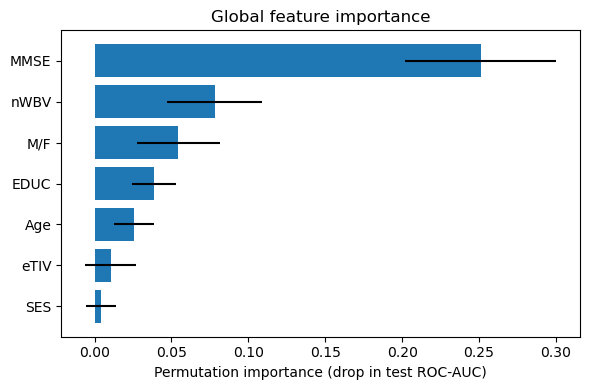

In [25]:
plt.figure(figsize=(6, 4))
plt.barh(perm_df["feature"], perm_df["importance_mean"], xerr=perm_df["importance_std"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation importance (drop in test ROC-AUC)")
plt.title("Global feature importance")
plt.tight_layout()
plt.show()


`MMSE` dominates, by a wide margin — unsurprising, since it's the most
direct cognitive-screening measure among the features. `nWBV` and `M/F` are
distant secondary contributors; `SES` and `eTIV` carry very little signal
once the others are accounted for. This ranking is a property of *this
model on this cohort* — it should be read as "what the model leans on," not
as a claim about which factors cause cognitive decline.


In [26]:
train_medians = X_train[NUMERIC_FEATURES].median()
train_mode_cat = X_train[CATEGORICAL_FEATURES].mode().iloc[0]


def occlusion_contribution(model, patient_row: pd.DataFrame):
    """Marginal contribution of each feature vs. a 'typical' (median/mode) patient."""
    base_p = model.predict_proba(patient_row)[0, 1]
    contributions = {}
    for feat in FEATURES:
        modified = patient_row.copy()
        modified[feat] = train_medians[feat] if feat in NUMERIC_FEATURES else train_mode_cat[feat]
        modified_p = model.predict_proba(modified)[0, 1]
        contributions[feat] = base_p - modified_p
    return base_p, contributions


example_idx = test_analysis["proba"].idxmax()
example_patient = X_test.loc[[example_idx]]
base_p, contribs = occlusion_contribution(locked_model, example_patient)

print("Example test patient (highest predicted risk in the test set):")
print(example_patient)
print(f"\nModel-predicted probability: {base_p:.3f}")
print("\nPer-feature contribution vs. a typical (median/mode) patient:")
for f, c in sorted(contribs.items(), key=lambda kv: -abs(kv[1])):
    direction = "higher" if c > 0 else "lower"
    print(f"  {f}: contributed toward a {direction} model prediction (delta={c:+.3f})")


Example test patient (highest predicted risk in the test set):
    Age  EDUC  SES  MMSE     eTIV      nWBV M/F
56   71    16  1.0  17.0  1562.23  0.685476   M

Model-predicted probability: 1.000

Per-feature contribution vs. a typical (median/mode) patient:
  MMSE: contributed toward a higher model prediction (delta=+0.268)
  M/F: contributed toward a higher model prediction (delta=+0.001)
  nWBV: contributed toward a higher model prediction (delta=+0.001)
  Age: contributed toward a higher model prediction (delta=+0.000)
  EDUC: contributed toward a lower model prediction (delta=-0.000)
  eTIV: contributed toward a lower model prediction (delta=-0.000)
  SES: contributed toward a higher model prediction (delta=+0.000)


## 18. Converted-subject longitudinal analysis — **exploratory / pilot only**

**Exploratory / pilot analysis.** The 14 Converted subjects (37 visits) are
already contributing their individual visits to the main model above (via
their per-visit CDR-based target), exactly as intended. This section is a
*separate*, purely descriptive look at how these subjects moved over time —
it does **not** train any model on future information, and it must **not**
be read as evidence that this notebook can reliably predict *future*
conversion from ~14 subjects. It is a small, hypothesis-generating look at
the data, appropriate for a portfolio project — not a validated
longitudinal prediction claim.


In [27]:
converted = df[df["Group"] == "Converted"].sort_values(["Subject ID", "Visit"]).copy()
converted["risk_probability"] = locked_model.predict_proba(converted[FEATURES])[:, 1]
converted["in_split"] = np.where(
    converted["Subject ID"].isin(train_subjects), "train",
    np.where(converted["Subject ID"].isin(test_subjects), "test", "?"))

print(f"Converted subjects: {converted['Subject ID'].nunique()}  |  visits: {len(converted)}")
converted[["Subject ID", "Visit", "MMSE", "nWBV", "CDR", "risk_probability", "in_split"]].head(15)


Converted subjects: 14  |  visits: 37


,Subject ID,Visit,MMSE,nWBV,CDR,risk_probability,in_split
33,OAS2_0018,1,30.0,0.715094,0.0,0.111568,train
34,OAS2_0018,3,29.0,0.713376,0.0,0.190977,train
35,OAS2_0018,4,27.0,0.695753,0.5,0.478719,train
36,OAS2_0020,1,29.0,0.693174,0.0,0.409452,test
37,OAS2_0020,2,28.0,0.676551,0.5,0.614850,test
38,OAS2_0020,3,26.0,0.666357,0.5,0.867993,test
57,OAS2_0031,1,30.0,0.718065,0.0,0.095926,train
58,OAS2_0031,2,30.0,0.719486,0.0,0.080772,train
59,OAS2_0031,3,28.0,0.695534,0.5,0.274631,train
81,OAS2_0041,1,27.0,0.771306,0.0,0.501018,train


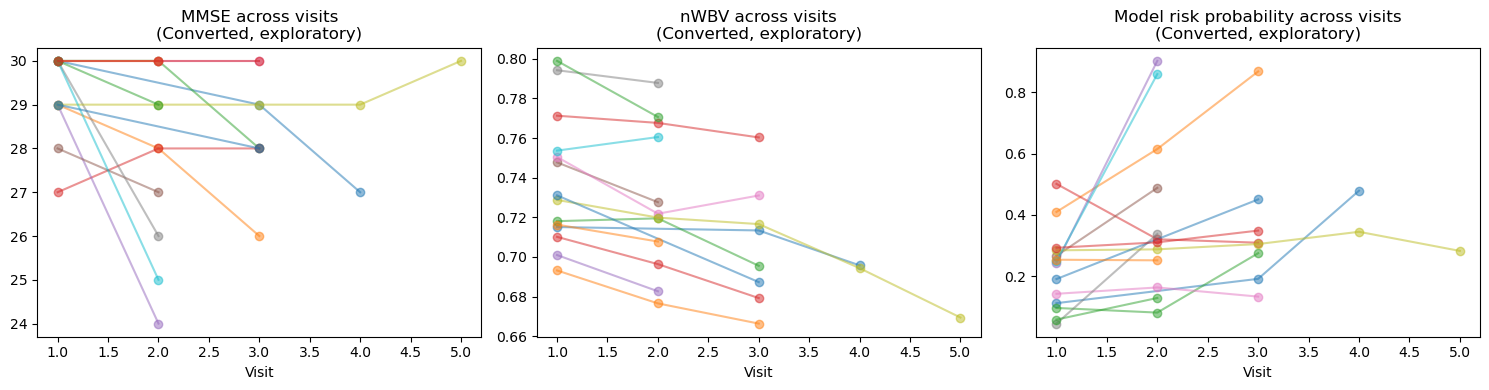

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for sid, g in converted.groupby("Subject ID"):
    axes[0].plot(g["Visit"], g["MMSE"], marker="o", alpha=0.5)
    axes[1].plot(g["Visit"], g["nWBV"], marker="o", alpha=0.5)
    axes[2].plot(g["Visit"], g["risk_probability"], marker="o", alpha=0.5)
axes[0].set_title("MMSE across visits\n(Converted, exploratory)")
axes[1].set_title("nWBV across visits\n(Converted, exploratory)")
axes[2].set_title("Model risk probability across visits\n(Converted, exploratory)")
for a in axes:
    a.set_xlabel("Visit")
plt.tight_layout()
plt.show()


Broadly, several Converted subjects show declining MMSE, declining nWBV,
and a rising model risk probability across visits — consistent with the
"Converted" label by construction (their CDR does cross the ≥ 0.5 line at
some point). This is presented as descriptive context only, with a sample
too small (14 subjects) to support any claim of reliable future-conversion
prediction.


## 19–20. `generate_priority()` and example inference

A single reusable function wraps the locked model, thresholds, and
explanation method into the interface a downstream app (e.g. a Streamlit
demo) would call. It never outputs a diagnosis — only a research-labeled
priority tier and a conservative, generic recommended action.


In [29]:
def generate_priority(patient_data: dict) -> dict:
    """
    patient_data: dict with keys Age, M/F, EDUC, SES, MMSE, eTIV, nWBV.
    Returns a research-prototype priority assessment. NOT a diagnosis.
    """
    row = pd.DataFrame([patient_data])[FEATURES]
    proba = float(locked_model.predict_proba(row)[0, 1])
    risk_score = round(proba * 100, 1)

    if proba < t_low:
        priority, action = "LOW", "Routine follow-up interval; no immediate escalation indicated."
    elif proba < t_high:
        priority, action = "MEDIUM", "Consider prioritizing for further clinical assessment."
    else:
        priority, action = "HIGH", "Recommend prioritizing for prompt clinical assessment."

    _, contribs = occlusion_contribution(locked_model, row)
    top_feats = sorted(contribs.items(), key=lambda kv: -abs(kv[1]))[:3]
    explanation = [
        f"{f} contributed toward a {'higher' if c > 0 else 'lower'} model prediction (delta={c:+.3f})"
        for f, c in top_feats
    ]

    return {
        "risk_probability": round(proba, 4),
        "risk_score": risk_score,
        "priority": priority,
        "recommended_action": action,
        "explanation": explanation,
        "disclaimer": "Prototype research score — not a clinical diagnosis or a validated probability of Alzheimer's disease.",
    }


In [30]:
sample_low = X_test.loc[[test_analysis["proba"].idxmin()]].iloc[0].to_dict()
sample_high = X_test.loc[[test_analysis["proba"].idxmax()]].iloc[0].to_dict()

print("Example 1 — real test-set patient with the lowest predicted risk:")
print(json.dumps(generate_priority(sample_low), indent=2))

print("\nExample 2 — real test-set patient with the highest predicted risk:")
print(json.dumps(generate_priority(sample_high), indent=2))


Example 1 — real test-set patient with the lowest predicted risk:
{
  "risk_probability": 0.0362,
  "risk_score": 3.6,
  "priority": "LOW",
  "recommended_action": "Routine follow-up interval; no immediate escalation indicated.",
  "explanation": [
    "nWBV contributed toward a lower model prediction (delta=-0.070)",
    "MMSE contributed toward a lower model prediction (delta=-0.031)",
    "Age contributed toward a higher model prediction (delta=+0.013)"
  ],
  "disclaimer": "Prototype research score \u2014 not a clinical diagnosis or a validated probability of Alzheimer's disease."
}

Example 2 — real test-set patient with the highest predicted risk:
{
  "risk_probability": 0.9996,
  "risk_score": 100.0,
  "priority": "HIGH",
  "recommended_action": "Recommend prioritizing for prompt clinical assessment.",
  "explanation": [
    "MMSE contributed toward a higher model prediction (delta=+0.268)",
    "M/F contributed toward a higher model prediction (delta=+0.001)",
    "nWBV contrib

## 21. Save artifacts for later inference (e.g. a Streamlit app)

Everything needed to run `generate_priority()` again later, without
retraining, is saved to `artifacts/`:
- the complete locked pipeline (preprocessing + model, calibrated if applicable) as a single joblib file
- a JSON metadata file with the feature list, thresholds, random seed, and headline test metrics


In [31]:
import os
os.makedirs("artifacts", exist_ok=True)

joblib.dump(locked_model, "artifacts/neuropath_v2_model.joblib")

metadata = {
    "project": "NeuroPath AI V2 - Current Risk/Priority Classification",
    "features": FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "selected_model": selected_model_name,
    "calibrated": bool(use_calibration),
    "priority_thresholds": {
        "low_medium": round(float(t_low), 3),
        "medium_high": round(float(t_high), 3),
    },
    "random_state": RANDOM_STATE,
    "sklearn_version": __import__("sklearn").__version__,
    "test_metrics": {k: round(float(v), 4) for k, v in test_metrics.items()},
    "note": "Prototype research thresholds - not clinically validated. Not a diagnostic system.",
}
with open("artifacts/neuropath_v2_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved: artifacts/neuropath_v2_model.joblib")
print("Saved: artifacts/neuropath_v2_metadata.json")
print(json.dumps(metadata, indent=2))


Saved: artifacts/neuropath_v2_model.joblib
Saved: artifacts/neuropath_v2_metadata.json
{
  "project": "NeuroPath AI V2 - Current Risk/Priority Classification",
  "features": [
    "Age",
    "EDUC",
    "SES",
    "MMSE",
    "eTIV",
    "nWBV",
    "M/F"
  ],
  "numeric_features": [
    "Age",
    "EDUC",
    "SES",
    "MMSE",
    "eTIV",
    "nWBV"
  ],
  "categorical_features": [
    "M/F"
  ],
  "selected_model": "LogisticRegression",
  "calibrated": true,
  "priority_thresholds": {
    "low_medium": 0.2,
    "medium_high": 0.4
  },
  "random_state": 42,
  "sklearn_version": "1.8.0",
  "test_metrics": {
    "accuracy": 0.8133,
    "precision": 0.9545,
    "recall_sensitivity": 0.6176,
    "specificity": 0.9756,
    "f1": 0.75,
    "roc_auc": 0.8709,
    "pr_auc": 0.8879,
    "brier": 0.1472
  },
  "note": "Prototype research thresholds - not clinically validated. Not a diagnostic system."
}


## 22. V2 summary and limitations

**What changed from V1:**
- Target moved from a subject-level diagnostic label (`Group`) to a per-visit, CDR-defined **current risk/priority** state, letting Converted subjects contribute naturally instead of being excluded.
- Splitting and cross-validation moved from (implicit) row-level to **subject-grouped**, closing the most serious potential leakage path in a longitudinal dataset.
- Added calibration analysis, out-of-fold-derived LOW/MEDIUM/HIGH triage thresholds, permutation-based global explanations, and patient-level occlusion explanations, none of which existed in V1.
- Compared three model families under identical, leakage-safe conditions instead of two.

**Headline test-set numbers** (see Section 15 for the full set; one-time
evaluation): the model reaches strong specificity and precision at the
default 0.5 cutoff, moderate recall at that same hard cutoff, and
substantially higher recall when read through the intended LOW-vs-flagged
triage framing — which is the framing this system is actually meant to be
used through.

**Known limitations:**
- Small dataset (150 subjects, 373 visits) → CV metrics have real fold-to-fold variance (see the std columns in Section 8); the test set (75 visits) is small enough that a handful of misclassifications shift metrics noticeably.
- `SES` is missing for 19 (Demented-group) visits — a data-quirk worth remembering, not something confirmed to be missing-at-random.
- Explanations use permutation importance and an occlusion-based local method rather than exact SHAP values, due to an offline environment without package-index access.
- Thresholds and calibration are prototype-level, tuned on a single grouped split rather than nested CV over multiple splits — a reasonable next step for more robust estimates.
- This is a research/portfolio prototype, not a validated clinical tool, and must never be used to make real diagnostic or treatment decisions.


## 23. Short V3 roadmap (future work only — not implemented here)

V2 deliberately stays within classical ML on tabular clinical/demographic
features. A possible V3 direction, **not implemented in this notebook**:

```
Raw MRI
  → preprocessing (skull-stripping, registration, normalization)
  → CNN / deep-learning feature extraction
  → MRI embeddings
  → fusion with clinical/cognitive features (this notebook's feature set)
  → multimodal prioritization model
```

This would require substantially more imaging data than the 373 visits
here, a validated preprocessing pipeline for raw MRI volumes, and a much
heavier compute/engineering budget than a hackathon/portfolio prototype —
it is intentionally scoped out of V2.
